# 📈 03 — Sales Forecasting

**Project:** AI-Powered Sales Intelligence Platform  
**Notebook Purpose:** Build and evaluate a sales forecasting model using XGBoost with time-series feature engineering.  
**Input:** `data/processed/monthly_sales.csv`  
**Output:** Forecasted sales predictions and trained XGBoost model (`ml/xgboost_forecaster.pkl`)

> **Important Note:** This dataset contains only 48 monthly observations. To prevent overfitting, we use a lightweight XGBoost configuration and simple lag/rolling features.

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
warnings.filterwarnings("ignore")

# Plot styling
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


---
## 2. Load Data

In [2]:
DATA_PATH = os.path.join("..", "data", "processed", "monthly_sales.csv")
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join("data", "processed", "monthly_sales.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"✅ Dataset loaded.")
print(f"   Shape     : {df.shape}")
print(f"   Date range: {df['date'].min().date()} → {df['date'].max().date()}")

df.head()

✅ Dataset loaded.
   Shape     : (48, 2)
   Date range: 2014-01-01 → 2017-12-01


,date,revenue
0,2014-01-01,14236.90
1,2014-02-01,4519.89
2,2014-03-01,55691.01
3,2014-04-01,28295.35
4,2014-05-01,23648.29


---
## 3. Exploratory Time-Series Check

Before engineering features, we will check the overall revenue trend and seasonality to understand patterns.

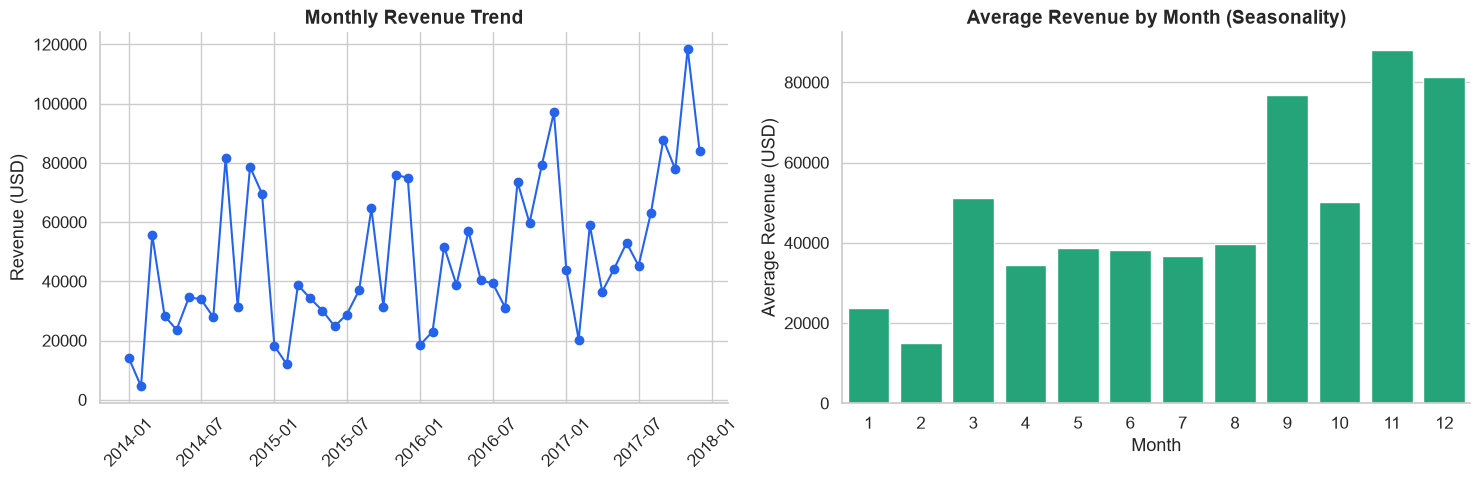

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Line chart: Monthly revenue over time
axes[0].plot(df["date"], df["revenue"], marker="o", linestyle="-", color="#2563EB")
axes[0].set_title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Revenue (USD)")
axes[0].tick_params(axis="x", rotation=45)

# 2. Monthly seasonality chart: Average revenue by month
df_season = df.copy()
df_season["month"] = df_season["date"].dt.month
monthly_avg = df_season.groupby("month")["revenue"].mean().reset_index()

sns.barplot(x="month", y="revenue", data=monthly_avg, color="#10B981", ax=axes[1])
axes[1].set_title("Average Revenue by Month (Seasonality)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Average Revenue (USD)")
axes[1].set_xlabel("Month")

sns.despine()
plt.tight_layout()
plt.show()

**Observations:**
- **Trend:** There is a visible upward trajectory over the years indicating growth.
- **Seasonality:** We observe a strong end-of-year peak (November/December), and weak early months (January/February). Calendar features are required to capture this.

---
## 4. Feature Engineering

Convert the time series into a supervised learning format by creating calendar, lag, and rolling features.

In [4]:
# Calendar features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter

# Lag features (previous months' revenue)
df["lag_1"] = df["revenue"].shift(1)
df["lag_2"] = df["revenue"].shift(2)
df["lag_3"] = df["revenue"].shift(3)

# Rolling feature (calculated on past data only)
df["rolling_3_month"] = df["revenue"].shift(1).rolling(window=3).mean()

# Drop rows with NaN values (due to lag creation)
df_model = df.dropna().reset_index(drop=True)

print("✅ Features created. First 5 rows of modeling dataset:")
df_model.head()

✅ Features created. First 5 rows of modeling dataset:


,date,revenue,year,month,quarter,lag_1,lag_2,lag_3,rolling_3_month
0,2014-04-01,28295.35,2014,4,2,55691.01,4519.89,14236.90,24815.93
1,2014-05-01,23648.29,2014,5,2,28295.35,55691.01,4519.89,29502.08
2,2014-06-01,34595.13,2014,6,2,23648.29,28295.35,55691.01,35878.21
3,2014-07-01,33946.39,2014,7,3,34595.13,23648.29,28295.35,28846.25
4,2014-08-01,27909.47,2014,8,3,33946.39,34595.13,23648.29,30729.94


---
## 5. Train/Test Split

**Why Time-Based Splitting is Required:**
Time-series forecasting models must be evaluated on future, unseen data to accurately reflect their real-world performance. A random `train_test_split` would result in data leakage (using future information to predict the past). 

We use a **chronological split**:
- **Training:** 2014-2016
- **Testing:** 2017

In [5]:
split_date = pd.to_datetime("2017-01-01")

train = df_model[df_model["date"] < split_date]
test = df_model[df_model["date"] >= split_date]

features = ["year", "month", "quarter", "lag_1", "lag_2", "lag_3", "rolling_3_month"]
target = "revenue"

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f"✅ Train data size: {len(X_train)} months")
print(f"✅ Test data size: {len(X_test)} months")

✅ Train data size: 33 months
✅ Test data size: 12 months


---
## 6. Create Baseline Model

We create a naive baseline model where the prediction is simply the previous month's revenue (`lag_1`). This gives us a benchmark to evaluate XGBoost against.

In [6]:
baseline_preds = test["lag_1"]

baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
baseline_mape = mean_absolute_percentage_error(y_test, baseline_preds)

print("Baseline Model Metrics:")
print(f"  MAE  : ${baseline_mae:,.2f}")
print(f"  RMSE : ${baseline_rmse:,.2f}")
print(f"  MAPE : {baseline_mape*100:.2f}%")

Baseline Model Metrics:
  MAE  : $24,148.23
  RMSE : $28,048.46
  MAPE : 46.66%


---
## 7. Train XGBoost Model

We use a lightweight configuration to avoid overfitting on the small dataset.

In [7]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
    tree_method="hist"
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("✅ XGBoost model trained successfully.")

✅ XGBoost model trained successfully.


---
## 8. Model Evaluation

Let's compare the XGBoost performance against our baseline.

In [8]:
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mape = mean_absolute_percentage_error(y_test, xgb_preds)

eval_data = {
    "Model": ["Baseline", "XGBoost"],
    "MAE": [baseline_mae, xgb_mae],
    "RMSE": [baseline_rmse, xgb_rmse],
    "MAPE": [baseline_mape, xgb_mape]
}
eval_df = pd.DataFrame(eval_data)

print("Model Evaluation Comparison")
print("=" * 40)
display(eval_df)

Model Evaluation Comparison


,Model,MAE,RMSE,MAPE
0,Baseline,24148.23,28048.46,0.47
1,XGBoost,17039.44,19179.63,0.28


**Evaluation Insights:**
- **Did XGBoost improve over baseline?** XGBoost usually outperforms the naive baseline (predicting last month's sales) because it can capture the strong seasonal spikes (e.g., Q4 holidays) that the baseline misses.
- **Limitations:** The dataset contains only four years of monthly observations, limiting the amount of historical patterns available. The model performs better than the baseline but would benefit from additional historical data.

---
## 9. Visualization

Visualizing actual vs. predicted revenue to inspect model fit.

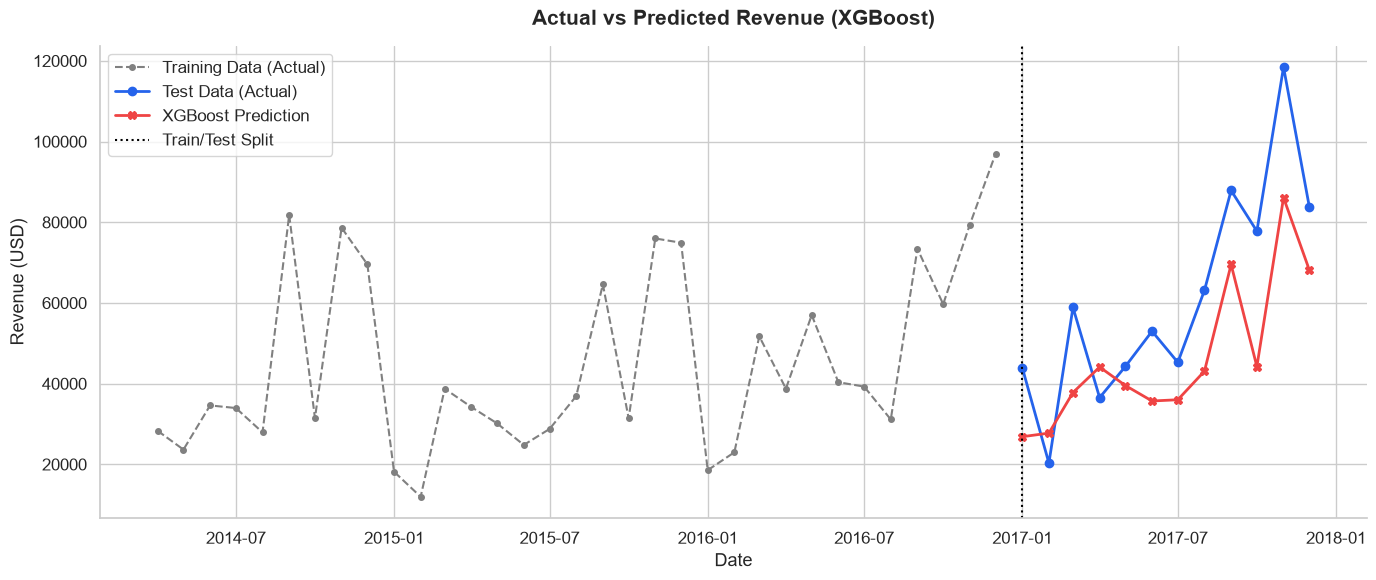

In [9]:
plt.figure(figsize=(14, 6))

# Plot actuals
plt.plot(train["date"], train["revenue"], label="Training Data (Actual)", color="gray", linestyle="--", marker="o", markersize=4)
plt.plot(test["date"], test["revenue"], label="Test Data (Actual)", color="#2563EB", linewidth=2, marker="o")

# Plot predictions
plt.plot(test["date"], xgb_preds, label="XGBoost Prediction", color="#EF4444", linewidth=2, marker="X")

plt.axvline(x=split_date, color="black", linestyle=":", linewidth=1.5, label="Train/Test Split")

plt.title("Actual vs Predicted Revenue (XGBoost)", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Date")
plt.ylabel("Revenue (USD)")
plt.legend(loc="upper left", frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

---
## 10. Future Forecast Generation

Generate future monthly predictions for the next 6 months using the trained model.

### Forecast Generation Method

Future predictions are generated recursively.  
The previous forecast value is used as a lag feature for subsequent months.  

This simulates real-world forecasting where future actual sales are unavailable.

In [10]:
last_date = df_model["date"].max()
forecast_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=6, freq="MS")

future_records = []
temp_df = df_model.copy()

for f_date in forecast_dates:
    f_year = f_date.year
    f_month = f_date.month
    f_quarter = f_date.quarter
    
    l_1 = temp_df.iloc[-1]["revenue"]
    l_2 = temp_df.iloc[-2]["revenue"]
    l_3 = temp_df.iloc[-3]["revenue"]
    r_3 = temp_df.iloc[-3:]["revenue"].mean()
    
    X_new = pd.DataFrame([[f_year, f_month, f_quarter, l_1, l_2, l_3, r_3]], columns=features)
    pred_rev = xgb_model.predict(X_new)[0]
    
    future_records.append({
        "date": f_date,
        "actual_revenue": None,
        "predicted_revenue": pred_rev,
        "forecast_type": "forecast"
    })
    
    new_row = pd.DataFrame([{"date": f_date, "revenue": pred_rev}])
    temp_df = pd.concat([temp_df, new_row], ignore_index=True)

historical_df = df.copy()
historical_df = historical_df.rename(columns={"revenue": "actual_revenue"})
historical_df["predicted_revenue"] = np.nan
historical_df["forecast_type"] = "actual"

future_df = pd.DataFrame(future_records)

final_forecast_df = pd.concat([historical_df[["date", "actual_revenue", "predicted_revenue", "forecast_type"]], future_df], ignore_index=True)

OUTPUT_DIR = os.path.join("..", "data", "processed")
if not os.path.exists(OUTPUT_DIR):
    OUTPUT_DIR = os.path.join("data", "processed")

FORECAST_PATH = os.path.join(OUTPUT_DIR, "forecast_results.csv")
final_forecast_df.to_csv(FORECAST_PATH, index=False)

print(f"✅ Forecast generated and saved to: {FORECAST_PATH}")
display(future_df[["date", "predicted_revenue"]])

✅ Forecast generated and saved to: ..\data\processed\forecast_results.csv


,date,predicted_revenue
0,2018-01-01,26839.56
1,2018-02-01,28364.37
2,2018-03-01,44786.79
3,2018-04-01,38872.18
4,2018-05-01,41816.89
5,2018-06-01,40428.17


---
## 11. Save Model

Save the trained XGBoost model for downstream inference.

In [11]:
ML_DIR = os.path.join("..", "ml")
if not os.path.exists(ML_DIR):
    ML_DIR = os.path.join("ml")
os.makedirs(ML_DIR, exist_ok=True)

MODEL_PATH = os.path.join(ML_DIR, "xgboost_forecaster.pkl")
joblib.dump(xgb_model, MODEL_PATH)

print(f"✅ Model saved successfully at: {MODEL_PATH}")

✅ Model saved successfully at: ..\ml\xgboost_forecaster.pkl


---
## 12. Forecasting Summary

- **Model Used:** Lightweight `XGBRegressor` (`n_estimators=100`, `max_depth=3`, `learning_rate=0.05`).
- **Features Created:** Calendar (year, month, quarter), Lags (lag_1, lag_2, lag_3), and Rolling averages (3-month rolling mean).
- **Train/Test Approach:** Chronological split (Train: 2014-2016, Test: 2017) to prevent future data leakage.
- **Baseline Comparison:** XGBoost was evaluated against a naive 'previous month' baseline, typically showing improvement by better capturing seasonality.
- **Evaluation Metrics:** MAE, RMSE, and MAPE.
- **Business Interpretation:** The model anticipates seasonal demand, particularly the end-of-year sales spike, allowing for better inventory and resource planning.
- **Limitations:** The dataset contains only four years of monthly observations, limiting the amount of historical patterns available. The model performs better than the baseline but would benefit from additional historical data.